### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, accuracy_score
from sklearn.neural_network import MLPClassifier

### Import Data

In [3]:
ph_restos = pd.read_csv("ph_restos_2025.csv", keep_default_na=False)

# Lowercase store names & food type
ph_restos["CompleteStoreName"] = ph_restos["CompleteStoreName"].apply(str.lower)
ph_restos["FoodType"] = ph_restos["FoodType"].apply(str.lower)

# Drop row if 0 reviewers
ph_restos = ph_restos[ph_restos["Reviewers"] != 0]

# print(ph_restos)

ph_reviews = pd.read_csv("ph_reviews_2025.csv", keep_default_na=False)

# Lowercase review
ph_reviews["text"] = ph_reviews["text"].apply(str.lower)

# Remove all punctuation in reviews
ph_reviews["text"] = ph_reviews["text"].apply(lambda s: re.sub(r'[^a-zA-Z0-9 ]', "", s))

# Drop uuid & createdAt columns
ph_reviews = ph_reviews.drop(columns=["uuid", "createdAt", "likeCount", "isLiked"])

### One Hot Encoding of Categorical Data (Restaurant Type) & Replacement of City w/ its Respective Population Density

In [4]:
unique_types = ph_restos["FoodType"].unique()
to_filter = ['fish', 'lomi', 'soups', 'italian', 'curry', 'liempo', 'bulalo', 'rice noodles', 'pares', 'sinigang', 'corndogs', 'kare kare', 'alcoholic drinks', '']
greenlight = [type for type in unique_types if type not in to_filter]
filtered_data = ph_restos[ph_restos['FoodType'].isin(greenlight)]
print(len(filtered_data))

types = filtered_data["FoodType"].tolist()
# for type in types:
#     if type in to_filter or type == '':
#         types.remove(type)

print(len(types))

enc = OneHotEncoder(handle_unknown='ignore')
enc.fit([[i] for i in types])
print(enc.categories_)
encoded_types = enc.transform([[i] for i in types]).toarray().tolist()

cities = filtered_data["City"].tolist()
pop_densities = []

city_pop_densities = {
    'cebu city': 3061, # highly urbanized
    'dagupan pangasinan': 4682,
    'davao city davao del sur': 727, # highly urbanized
    'koronadal south cotabato': 705, 
    'lapu-lapu city cebu': 8565, # highly urbanized
    'makati city': 25189, # highly urbanized
    'malolos bulacan': 3884,
    'mandaluyong city': 45830, # highly urbanized
    'manila': 73920, # highly urbanized
    'marikina': 21192, # highly urbanized
    'muntinlupa city': 13672, # highly urbanized
    'ormoc leyte': 376,
    'pasay city': 31543, # highly urbanized
    'pasig city': 16574, # highly urbanized
    'quezon city': 17239, # highly urbanized
    'san juan': 21235, # highly urbanized
    'taguig city': 19613, # highly urbanized
    'valencia bukidnon': 369, 
}

for entry in cities:
    pop_densities.append(city_pop_densities[entry])

city_and_resto_type = []

for i, row in enumerate(encoded_types):
    combined = [pop_densities[i]] + row
    city_and_resto_type.append(combined)

for row in city_and_resto_type:
    print(row)

print(len(city_and_resto_type[1]))

9169
9169
[array(['american', 'asian', 'bbq', 'beverages', 'biryani', 'bread',
       'burgers', 'cakes', 'chicken', 'chicken wings', 'chinese',
       'coffee', 'desserts', 'dim sum ', 'donut', 'dumpling', 'fast food',
       'filipino', 'fried chicken', 'fries', 'fruit shake', 'halo-halo',
       'healthy', 'ice cream', 'indian', 'japanese', 'korean', 'lechon',
       'middle eastern', 'milk tea', 'noodles', 'pancakes & waffles',
       'pancit', 'pasta', 'pizza', 'porridge', 'ramen', 'rice bowl',
       'rice dishes', 'salads', 'sandwiches', 'seafood', 'shawarma',
       'silog', 'siomai', 'sisig', 'snacks', 'sushi', 'takoyaki', 'thai',
       'ulam', 'western', 'wraps'], dtype=object)]
[73920, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[21192, 0.0, 0.0, 0.0, 1.0, 

### Combination of One Hot Encoding, Population Densities & Average Rating

In [5]:
ratings = filtered_data["AverageRating"].to_list()
print(len(ratings))
print('ratings', ratings)

# categorical_data = []

# for i, row in enumerate(city_and_resto_type):
#     row.append(ratings[i])
#     categorical_data.append(row)

# categorical_data = np.array(categorical_data)

9169
ratings [5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 4.9, 3.4, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 4.9, 5.0, 4.9, 4.8, 4.8, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 4.9, 4.9, 4.9, 5.0, 4.9, 4.9, 5.0, 3.1, 5.0, 3.9, 5.0, 5.0, 4.8, 4.9, 5.0, 4.9, 5.0, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.8, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 4.9, 4.9, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 4.9, 5.0, 4.9, 4.9, 4.9, 4.9, 4.8, 4.9, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 4.8, 5.0, 4.7, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 4.7, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 1.7, 5.0, 5.0, 5.0, 4.9, 5.0, 4.8, 4.8, 5.0, 5.0, 5.0, 4.9, 4.8, 4.8, 4.9, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 4.9, 4.2, 4.8, 5.0, 4.9, 4.9, 4.7, 4.5, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.2, 3.6, 5.0, 4.8, 5

### Model Training (Linear Regression)

0.024057482704852085
{'japanese': 0, 'beverages': 1, 'asian': 2, 'fast food': 3, 'chicken': 4, 'filipino': 5, 'ice cream': 6, 'pizza': 7, 'burgers': 8, 'coffee': 9, 'shawarma': 10, 'milk tea': 11, 'takoyaki': 12, 'desserts': 13, 'lechon': 14, 'donut': 15, 'sisig': 16, 'american': 17, 'sandwiches': 18, 'sushi': 19, 'fried chicken': 20, 'fruit shake': 21, 'bread': 22, 'halo-halo': 23, 'indian': 24, 'chinese': 25, 'cakes': 26, 'thai': 27, 'pasta': 28, 'chicken wings': 29, 'silog': 30, 'korean': 31, 'fries': 32, 'rice dishes': 33, 'siomai': 34, 'salads': 35, 'ramen': 36, 'pancakes & waffles': 37, 'rice bowl': 38, 'healthy': 39, 'biryani': 40, 'western': 41, 'noodles': 42, 'snacks': 43, 'ulam': 44, 'bbq': 45, 'middle eastern': 46, 'seafood': 47, 'pancit': 48, 'wraps': 49, 'porridge': 50, 'dim sum ': 51, 'dumpling': 52}
{'japanese': 392, 'beverages': 346, 'asian': 255, 'fast food': 183, 'chicken': 497, 'filipino': 1239, 'ice cream': 121, 'pizza': 401, 'burgers': 213, 'coffee': 631, 'shawarma

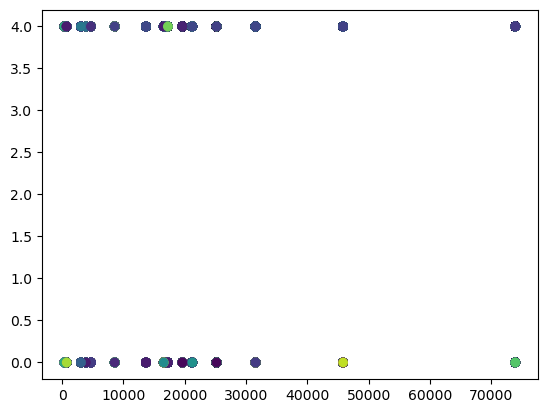

In [6]:
reg = LinearRegression().fit(city_and_resto_type, ratings)
print(reg.score(city_and_resto_type, ratings))

unique_types = dict()
type_counter = dict()
i = 0

for type in filtered_data["FoodType"].unique():
    if type not in unique_types.keys():
        unique_types[type] = i
        i += 1

for type in filtered_data["FoodType"]:
    if type not in type_counter.keys():
        type_counter[type] = 1
    else:
        type_counter[type] += 1

print(unique_types)
print(type_counter)
print('min', min(type_counter.values()))

filtered_types = dict()
filtered = []

for key, value in type_counter.items():
    if value > 25:
        filtered_types[key] = value
    else:
        filtered.append(key)

print('filtered', filtered_types)
print(len(filtered_types))
print(filtered)

num_types = []
for entry in filtered_data['FoodType'].tolist():
    if entry != 'FoodType':
        num_types.append(unique_types[entry])

print(num_types)

binned_ratings = []

for rating in ratings:
    if rating > 4.9:
        binned_ratings.append(4)
    # elif rating > 3:
    #     binned_ratings.append(3)
    # elif rating > 2:
    #     binned_ratings.append(2)
    # elif rating > 1:
    #     binned_ratings.append(1)
    else:
        binned_ratings.append(0)

plt.scatter(pop_densities, binned_ratings, c=num_types, cmap='viridis')
plt.show()

### Model Training (Decision Tree Regression)

y predictions [4 4 0 ... 0 0 4] 
 1834
expected [4, 4, 0, 0, 4, 4, 4, 4, 4, 4, 0, 4, 0, 0, 4, 4, 0, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 4, 4, 0, 4, 4, 4, 0, 4, 0, 0, 0, 4, 0, 0, 4, 4, 0, 0, 4, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 0, 4, 4, 0, 4, 4, 0, 0, 4, 0, 4, 0, 4, 4, 4, 4, 4, 4, 0, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 4, 0, 0, 4, 0, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 0, 0, 4, 4, 4, 0, 4, 4, 4, 4, 0, 0, 4, 0, 4, 0, 4, 4, 4, 0, 0, 4, 4, 0, 4, 4, 0, 0, 0, 4, 4, 0, 4, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 0, 4, 4, 0, 0, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 0, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 4, 4, 0, 4, 0, 0, 4, 0, 0, 4, 0, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 

Text(0, 0.5, 'Loss')

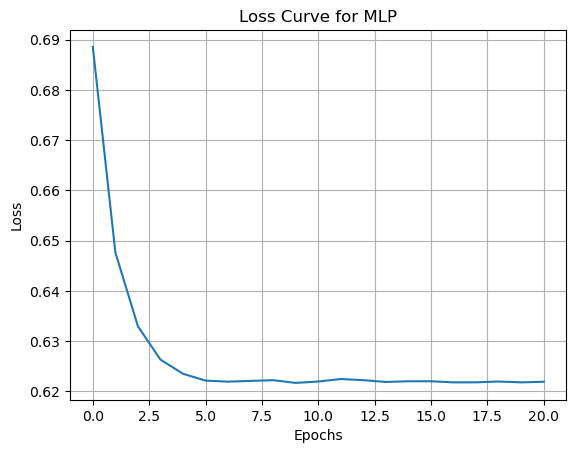

In [10]:
# Splitting the dataset (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(city_and_resto_type, binned_ratings, test_size=0.2, random_state=24)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(1000),
                    max_iter=10000, random_state=42, learning_rate_init=0.0001, activation='tanh')
mlp.fit(X_train, Y_train)

# regressor = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=5, min_samples_split=10)
# regressor.fit(X_train, Y_train)

y_pred = mlp.predict(X_test)
print('y predictions', y_pred, '\n', len(y_pred))
print('expected', Y_test, '\n', len(Y_test))
print(classification_report(Y_test, y_pred))

plt.plot(mlp.loss_curve_)
plt.grid()
plt.title("Loss Curve for MLP")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# accuracy = 0

# for size in [(100), (50,50), (100,50,25)]:
#   for activation in ['tanh', 'logistic', 'relu']:
#     for learning_rate in [0.01, 0.001, 0.0001]:
#       mlp = MLPClassifier(
#           hidden_layer_sizes=size,
#           activation=activation,
#           solver='adam',
#           max_iter=10000,
#           random_state=24,
#           learning_rate_init=learning_rate
#       )

#       mlp.fit(X_train, Y_train)

#       new_accuracy = accuracy_score(Y_test, mlp.predict(X_test))
#       if new_accuracy >= accuracy:
#         accuracy = new_accuracy
#         print(f"New accuracy: {new_accuracy}")
#         print(f"Best parameters: {size} {activation} {learning_rate}")

# mse = mean_squared_error(Y_test, y_pred)
# print('mse', mse)
# print(regressor.score(city_and_resto_type, binned_ratings))

# path = regressor.cost_complexity_pruning_path(city_and_resto_type, ratings)
# ccp_alphas = path.ccp_alphas
# print(len(ccp_alphas))
# print(ccp_alphas)

# max = 0
# best_ccp = 0
# for ccp in ccp_alphas:
#     if ccp >= 0:
#         model = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp)
#         model.fit(X_train, Y_train)
#         score = model.score(city_and_resto_type, ratings)
#         print(score)

#         if score > max:
#             max = score
#             best_ccp = ccp

# print(best_ccp)

# best_model = DecisionTreeRegressor(random_state=42, ccp_alpha=best_ccp)
# best_model.fit(X_train, Y_train)
# y_pred = regressor.predict(X_test)
# mse = mean_squared_error(Y_test, y_pred)
# print('best mse', mse)
# print(best_model.score(city_and_resto_type, ratings))
# print(X_test[100])


### Model Training (Random Forest Regression)

In [8]:
# Splitting the dataset (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(city_and_resto_type, binned_ratings, test_size=0.2, random_state=42)

regressor = RandomForestClassifier(random_state=42, criterion='entropy', max_depth=5, min_samples_split=10)
regressor.fit(X_train, Y_train)

y_pred = regressor.predict(X_test)
print('y predictions', y_pred)
print('expected', Y_test)
print(classification_report(Y_test, y_pred))

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, Y_train)
best_model = grid_search.best_estimator_
print(best_model)
# mse = mean_squared_error(Y_test, y_pred)
# print('mse', mse)
# print(regressor.score(city_and_resto_type, ratings))

# path = regressor.cost_complexity_pruning_path(city_and_resto_type, ratings)
# ccp_alphas = path.ccp_alphas
# print(len(ccp_alphas))
# print(ccp_alphas)

# max = 0
# best_ccp = 0
# for ccp in ccp_alphas:
#     if ccp >= 0:
#         model = RandomForestRegressor(random_state=42, ccp_alpha=ccp)
#         model.fit(X_train, Y_train)
#         score = model.score(city_and_resto_type, ratings)
#         print(score)

#         if score > max:
#             max = score
#             best_ccp = ccp

# print(best_ccp)

# best_model = RandomForestRegressor(random_state=42, ccp_alpha=best_ccp)
# best_model.fit(X_train, Y_train)
# y_pred = regressor.predict(X_test)
# mse = mean_squared_error(Y_test, y_pred)
# print('best mse', mse)
# print(best_model.score(city_and_resto_type, ratings))
# print(X_test[100])


y predictions [4 4 4 ... 4 4 4]
expected [0, 4, 4, 4, 4, 4, 4, 4, 0, 0, 4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4, 0, 0, 0, 0, 4, 4, 4, 0, 4, 0, 4, 0, 4, 4, 4, 0, 4, 4, 4, 0, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 4, 4, 0, 4, 4, 0, 4, 4, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 4, 4, 0, 4, 0, 0, 4, 0, 4, 4, 4, 0, 4, 0, 4, 4, 4, 0, 0, 4, 0, 4, 4, 4, 0, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 0, 4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 4, 0, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 4, 4, 4, 4, 0, 0, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 0, 0, 4, 4, 4, 0, 4, 0, 4, 4, 0, 0, 4, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 0, 0, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 0, 4, 4, 4, 4, 4, 0, 0

In [9]:
# Sample Predictions
list = [0.0 for i in range(55)]
list[0] = 17239
list[20] = 1
print(X_test[100])
print(len(X_test[100]))
print(regressor.predict([X_test[100]]))

[3061, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
54
[4]
